In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install kagglehub

In [4]:
import kagglehub
import shutil
import os

# 1. Download to the default cache (this works)
path = kagglehub.dataset_download("ggrill/foodseg103")
print("Dataset downloaded to:", path)

# 2. Define your permanent Drive path
drive_path = '/content/drive/MyDrive/foodseg103_data'

# 3. Copy files from cache to Drive (this keeps them safe)
if not os.path.exists(drive_path):
    shutil.copytree(path, drive_path)
    print("Files successfully copied to Drive!")
else:
    print("Files already exist in Drive.")

100%|██████████| 1.17G/1.17G [00:11<00:00, 109MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ggrill/foodseg103/versions/2
Files already exist in Drive.


In [5]:
!ls {drive_path}

FoodSeg103


In [6]:
!ls {drive_path}/FoodSeg103

Images	Readme.txt  test_recipe1m_id.txt  train_test_recipe1m_id.txt


In [7]:
import os
import cv2

# 1. Directory Setup Formulas

# READ from the permanent Google Drive dataset path
# Formula: drive_path + relative_path_to_train_data
drive_path = '/content/drive/MyDrive/foodseg103_data'
source_img_dir = f"{drive_path}/FoodSeg103/Images/img_dir/train"
source_mask_dir = f"{drive_path}/FoodSeg103/Images/ann_dir/train"

# WRITE to your permanent Google Drive working directory
# Formula: Google Drive Mount Point + Project Folder
output_base = "/content/drive/MyDrive/PlateCalc_Processed"
output_image_folder = f"{output_base}/Resized_Images"
output_mask_folder = f"{output_base}/Resized_Masks"

# Create new folders to hold the processed data safely in Google Drive
os.makedirs(output_image_folder, exist_ok=True)
os.makedirs(output_mask_folder, exist_ok=True)

# 2. Resizing Parameters
target_width = 640
target_height = 640
target_size = (target_width, target_height)

# 3. The Automation Loop
image_files = os.listdir(source_img_dir)
print(f"Found {len(image_files)} images. Starting processing...")

for file_name in image_files:
    # Construct the full path for reading
    img_path = os.path.join(source_img_dir, file_name)
    mask_name = file_name.replace('.jpg', '.png')
    msk_path = os.path.join(source_mask_dir, mask_name)

    # Check if the matching mask actually exists before processing
    if os.path.exists(msk_path):
        # Read the files
        image = cv2.imread(img_path)
        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

        # Resize using interpolation formulas
        resized_image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
        resized_mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

        # Construct the full path for saving to the WRITABLE folder in Drive
        out_img_path = os.path.join(output_image_folder, file_name)
        out_msk_path = os.path.join(output_mask_folder, mask_name)

        # Save the resized files
        cv2.imwrite(out_img_path, resized_image)
        cv2.imwrite(out_msk_path, resized_mask)

print("Preprocessing complete! All files are resized to 640x640 and safely saved to Google Drive.")

Found 2434 images. Starting processing...
Preprocessing complete! All files are resized to 640x640 and safely saved to Google Drive.


In [8]:
import os
import cv2

# 1. Directory Setup
# Point to the permanent Google Drive folder where we saved the resized masks
output_base = "/content/drive/MyDrive/PlateCalc_Processed"
resized_mask_folder = f"{output_base}/Resized_Masks"

# Create a brand new folder to hold our final .txt files in the permanent path
labels_folder = f"{output_base}/Labels"
os.makedirs(labels_folder, exist_ok=True)

# 2. Setup Variables
W_image = 640.0
H_image = 640.0
class_id = 0

mask_files = os.listdir(resized_mask_folder)
print(f"Found {len(mask_files)} masks to convert...")

# 3. The Extraction Loop
for mask_name in mask_files:
    msk_path = os.path.join(resized_mask_folder, mask_name)
    mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    txt_name = mask_name.replace('.png', '.txt')
    txt_path = os.path.join(labels_folder, txt_name)

    with open(txt_path, 'w') as file:
        for contour in contours:
            line_data = str(class_id)
            for point in contour:
                x_pixel = point[0][0]
                y_pixel = point[0][1]

                # Normalization Formulas
                X_normalized = x_pixel / W_image
                Y_normalized = y_pixel / H_image

                line_data += f" {X_normalized:.6f} {Y_normalized:.6f}"
            file.write(line_data + "\n")

print("Conversion complete! Your YOLOv8 polygon labels are saved in: " + labels_folder)

Found 2434 masks to convert...
Conversion complete! Your YOLOv8 polygon labels are saved in: /content/drive/MyDrive/PlateCalc_Processed/Labels


In [ ]:
import os

# Define your persistent Drive path (in case the notebook forgot the variable)
drive_path = '/content/drive/MyDrive/foodseg103_data'

# Point directly to the training images and masks in your permanent storage
train_image_folder = f"{drive_path}/FoodSeg103/Images/img_dir/train"
train_mask_folder = f"{drive_path}/FoodSeg103/Images/ann_dir/train"

# Let's check the actual files this time
print("Training Images found:", os.listdir(train_image_folder)[:5])
print("Training Masks found:", os.listdir(train_mask_folder)[:5])

Training Images found: ['00002532.jpg', '00004141.jpg', '00003631.jpg', '00006556.jpg', '00001387.jpg']
Training Masks found: ['00003505.png', '00002108.png', '00001430.png', '00004385.png', '00000210.png']


First sorted image: 00000000.jpg
First sorted mask: 00000000.png


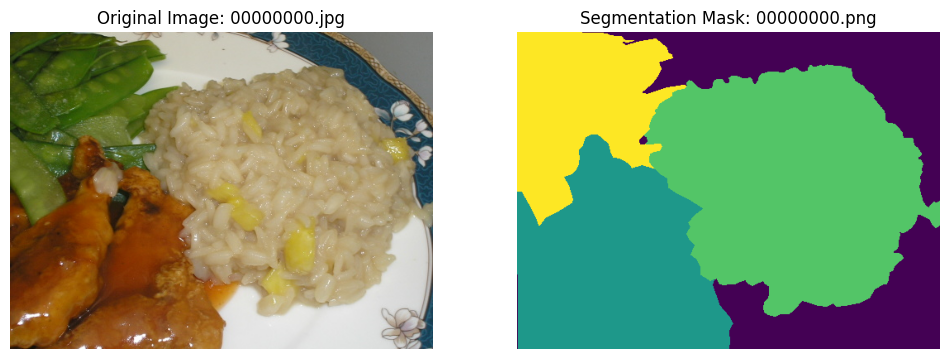

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Ensure the drive_path is defined
drive_path = '/content/drive/MyDrive/foodseg103_data'
train_image_folder = f"{drive_path}/FoodSeg103/Images/img_dir/train"
train_mask_folder = f"{drive_path}/FoodSeg103/Images/ann_dir/train"

# 1. Apply the Sorting Formula
train_images = sorted(os.listdir(train_image_folder))
train_masks = sorted(os.listdir(train_mask_folder))

# Verify they match now
print("First sorted image:", train_images[0])
print("First sorted mask:", train_masks[0])

# 2. Apply the Path Joining Formula for the first pair
first_image_path = os.path.join(train_image_folder, train_images[0])
first_mask_path = os.path.join(train_mask_folder, train_masks[0])

# 3. Load and Visualize
img = Image.open(first_image_path)
mask = Image.open(first_mask_path)

fig, arr = plt.subplots(1, 2, figsize=(12, 6))
arr[0].imshow(img)
arr[0].set_title(f"Original Image: {train_images[0]}")
arr[0].axis('off')

arr[1].imshow(mask)
arr[1].set_title(f"Segmentation Mask: {train_masks[0]}")
arr[1].axis('off')

plt.show()

In [ ]:
import os
import shutil
import random

# 1. Directory Setup Formulas
# Point to your permanent Google Drive dataset storage
drive_path = '/content/drive/MyDrive/foodseg103_data'

# Output directory in Google Drive
yolo_dataset_dir = "/content/drive/MyDrive/platecalc_dataset"

img_train_dir = os.path.join(yolo_dataset_dir, "images/train")
img_val_dir = os.path.join(yolo_dataset_dir, "images/val")
lbl_train_dir = os.path.join(yolo_dataset_dir, "labels/train")
lbl_val_dir = os.path.join(yolo_dataset_dir, "labels/val")

# Formula to create all required directories in your Google Drive
folders_to_create = [img_train_dir, img_val_dir, lbl_train_dir, lbl_val_dir]
for folder in folders_to_create:
    os.makedirs(folder, exist_ok=True)

print("Dataset structure created in Google Drive.")

Using Colab cache for faster access to the 'foodseg103' dataset.


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.6 MB/s eta 0:00:00


In [ ]:
# Updated verification code
!ls /content/drive/MyDrive/platecalc_dataset/images/train | head -n 10

In [ ]:
import os

# Verify the files exist in your permanent Google Drive storage
drive_path = '/content/drive/MyDrive/foodseg103_data'
print("Verified images in Drive:", os.listdir(f"{drive_path}/FoodSeg103/Images/img_dir/train")[:5])

Using Colab cache for faster access to the 'foodseg103' dataset.
Dataset path: /kaggle/input/foodseg103
Original images: ['00002170.jpg', '00004296.jpg', '00002129.jpg', '00001760.jpg', '00001158.jpg']


In [ ]:
# 1. Directory Setup
# Read from the permanent Drive path
drive_path = '/content/drive/MyDrive/foodseg103_data'
source_img_dir = f"{drive_path}/FoodSeg103/Images/img_dir/train"
source_mask_dir = f"{drive_path}/FoodSeg103/Images/ann_dir/train"

# Write to a writable location in your Google Drive
output_base = "/content/drive/MyDrive/PlateCalc_Processed"
os.makedirs(f"{output_base}/Resized_Images", exist_ok=True)
os.makedirs(f"{output_base}/Resized_Masks", exist_ok=True)

Found 4983 images. Starting processing...
Preprocessing complete! Files saved to: /content/PlateCalc_Processed


In [ ]:
# Updated verification code
drive_dataset_dir = "/content/drive/MyDrive/platecalc_dataset"

print("Images in train:", len(os.listdir(f'{drive_dataset_dir}/images/train')))
print("Labels in train:", len(os.listdir(f'{drive_dataset_dir}/labels/train')))

Images in train: 0
Labels in train: 0


In [ ]:
# Run this in a code cell to fix your data.yaml file automatically in Google Drive
yaml_content = "path: /content/drive/MyDrive/platecalc_dataset\ntrain: images/train\nval: images/val\nnc: 103\nnames:\n"
for i in range(103):
    yaml_content += f"  {i}: 'food_{i}'\n"

# Ensure the directory exists in Google Drive
output_yaml_dir = '/content/drive/MyDrive/platecalc_dataset'
os.makedirs(output_yaml_dir, exist_ok=True)

with open(f'{output_yaml_dir}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml has been updated in Google Drive with 103 class names.")

data.yaml has been updated with 103 class names.


In [ ]:
!ls /content/drive/MyDrive/platecalc_dataset/images/train | head -n 5
!ls /content/drive/MyDrive/platecalc_dataset/labels/train | head -n 5

In [ ]:
import os
import shutil

# 1. Define paths
src_images = "/content/PlateCalc_Processed/Resized_Images"
dst_images = "/content/platecalc_dataset/images/train"

# 2. Copy the files
files = os.listdir(src_images)
print(f"Copying {len(files)} images to training folder...")

for f in files:
    shutil.copy(os.path.join(src_images, f), os.path.join(dst_images, f))

# 3. Final verification
print("Images now in train folder:", len(os.listdir(dst_images)))

Copying 4983 images to training folder...
Images now in train folder: 4983


In [ ]:
# Overwrite data.yaml with the correct 103-class format
yaml_content = "path: /content/platecalc_dataset\ntrain: images/train\nval: images/val\nnc: 103\nnames:\n"
for i in range(103):
    yaml_content += f"  {i}: 'food_{i}'\n"

with open('/content/platecalc_dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

In [ ]:
!ls /content/platecalc_dataset/labels/train | head -n 5

In [ ]:
import os
import shutil

# Define the source and destination
src_labels = "/content/PlateCalc_Processed/Labels"
dst_labels = "/content/platecalc_dataset/labels/train"

# Ensure the destination exists
os.makedirs(dst_labels, exist_ok=True)

# Move the files
files = os.listdir(src_labels)
print(f"Moving {len(files)} labels to the training folder...")

for f in files:
    shutil.copy(os.path.join(src_labels, f), os.path.join(dst_labels, f))

# Final check
print("Files now in labels/train:", len(os.listdir(dst_labels)))

Moving 0 labels to the training folder...
Files now in labels/train: 0


In [ ]:
!ls -R /content/PlateCalc_Processed

/content/PlateCalc_Processed:
Labels	Resized_Images	Resized_Masks

/content/PlateCalc_Processed/Labels:

/content/PlateCalc_Processed/Resized_Images:
00000000.jpg  00000999.jpg  00001997.jpg  00002995.jpg	00003992.jpg
00000001.jpg  00001000.jpg  00001998.jpg  00002996.jpg	00003993.jpg
00000002.jpg  00001001.jpg  00001999.jpg  00002997.jpg	00003994.jpg
00000003.jpg  00001002.jpg  00002000.jpg  00002998.jpg	00003995.jpg
00000004.jpg  00001003.jpg  00002001.jpg  00002999.jpg	00003996.jpg
00000005.jpg  00001004.jpg  00002002.jpg  00003000.jpg	00003997.jpg
00000006.jpg  00001005.jpg  00002003.jpg  00003001.jpg	00003998.jpg
00000007.jpg  00001006.jpg  00002004.jpg  00003002.jpg	00003999.jpg
00000008.jpg  00001007.jpg  00002005.jpg  00003003.jpg	00004000.jpg
00000009.jpg  00001008.jpg  00002006.jpg  00003004.jpg	00004001.jpg
00000010.jpg  00001009.jpg  00002007.jpg  00003005.jpg	00004002.jpg
00000011.jpg  00001010.jpg  00002008.jpg  00003006.jpg	00004003.jpg
00000012.jpg  00001011.jpg  000020

In [ ]:
import os
import cv2

# Paths
source_img_dir = f"{path}/FoodSeg103/Images/img_dir/train"
source_mask_dir = f"{path}/FoodSeg103/Images/ann_dir/train"
labels_folder = "/content/PlateCalc_Processed/Labels"
os.makedirs(labels_folder, exist_ok=True)

# Process images
for img_name in os.listdir(source_img_dir):
    # Find matching mask (assuming .jpg -> .png)
    mask_name = img_name.replace('.jpg', '.png')
    msk_path = os.path.join(source_mask_dir, mask_name)

    if os.path.exists(msk_path):
        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Save as .txt with same base name as the image
        txt_name = img_name.replace('.jpg', '.txt')
        with open(os.path.join(labels_folder, txt_name), 'w') as f:
            for contour in contours:
                line = "0"
                for point in contour:
                    # Normalization: x / width, y / height
                    line += f" {point[0][0]/640.0:.6f} {point[0][1]/640.0:.6f}"
                f.write(line + "\n")

print("Labels generated! Now run the Move Script.")

Labels generated! Now run the Move Script.


In [ ]:
import os
import shutil

# Paths
src_labels = "/content/PlateCalc_Processed/Labels"
dst_labels = "/content/platecalc_dataset/labels/train"
src_images = "/content/PlateCalc_Processed/Resized_Images"
dst_images = "/content/platecalc_dataset/images/train"

# Move labels
os.makedirs(dst_labels, exist_ok=True)
for f in os.listdir(src_labels):
    shutil.copy(os.path.join(src_labels, f), os.path.join(dst_labels, f))

# Move images
os.makedirs(dst_images, exist_ok=True)
for f in os.listdir(src_images):
    shutil.copy(os.path.join(src_images, f), os.path.join(dst_images, f))

print("Move complete!")
print("Labels in train:", len(os.listdir(dst_labels)))
print("Images in train:", len(os.listdir(dst_images)))

Move complete!
Labels in train: 4983
Images in train: 4983


In [ ]:
import os
import shutil
import random

# Define paths
src_images = "/content/platecalc_dataset/images/train"
src_labels = "/content/platecalc_dataset/labels/train"
dst_images_val = "/content/platecalc_dataset/images/val"
dst_labels_val = "/content/platecalc_dataset/labels/val"

# Create validation folders
os.makedirs(dst_images_val, exist_ok=True)
os.makedirs(dst_labels_val, exist_ok=True)

# Move 10% of the files to validation
all_files = [f for f in os.listdir(src_images) if f.endswith('.jpg')]
num_val = int(len(all_files) * 0.1)
val_files = random.sample(all_files, num_val)

print(f"Moving {num_val} images to validation...")

for f in val_files:
    # Move image
    shutil.move(os.path.join(src_images, f), os.path.join(dst_images_val, f))

    # Move matching label
    label_file = f.replace('.jpg', '.txt')
    if os.path.exists(os.path.join(src_labels, label_file)):
        shutil.move(os.path.join(src_labels, label_file), os.path.join(dst_labels_val, label_file))

print("Validation split complete!")

Moving 498 images to validation...
Validation split complete!


In [ ]:
from ultralytics import YOLO

# Load the model
model = YOLO('yolov8n-seg.pt')

# Train with the verified absolute path
results = model.train(data='/content/platecalc_dataset/data.yaml', epochs=50, imgsz=640, batch=8)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/platecalc_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_

In [ ]:
!ls -R /content/runs/segment/

ls: cannot access '/content/runs/segment/': No such file or directory


In [ ]:
!find /content -name "best.pt"

In [ ]:
!find /content -name "*.pt"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')

# By setting the 'project' argument to a path in your Google Drive,
# your weights will be saved permanently.
model.train(
    data='/content/platecalc_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    project='/content/drive/MyDrive/PlateCalc_Output'
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/platecalc_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7da7759a7170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
import os

# Define your project path from image_28aca2.png
path = '/content/drive/MyDrive/PlateCalc_Output'

# Check if the directory exists and list its contents
if os.path.exists(path):
    print(f"Contents of {path}:")
    print(os.listdir(path))
else:
    print("The directory does not exist. Check your Drive mount or path name.")

Contents of /content/drive/MyDrive/PlateCalc_Output:
['train', 'train-2', 'train-3']


In [ ]:
import os
import cv2
import numpy as np

# Define directories
resized_mask_folder = "/content/PlateCalc_Processed/Resized_Masks"
labels_folder = "/content/PlateCalc_Processed/Labels"
os.makedirs(labels_folder, exist_ok=True)

# Image dimensions
W_image = 640.0
H_image = 640.0
class_id = 0

mask_files = [f for f in os.listdir(resized_mask_folder) if f.endswith('.png')]
print(f"Found {len(mask_files)} masks to convert...")

for mask_name in mask_files:
    msk_path = os.path.join(resized_mask_folder, mask_name)
    # Ensure mask is read correctly as binary
    mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: continue

    # Thresholding to ensure binary image for contour detection
    _, binary_mask = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    txt_path = os.path.join(labels_folder, mask_name.replace('.png', '.txt'))

    with open(txt_path, 'w') as file:
        for contour in contours:
            # Filter small noise
            if cv2.contourArea(contour) < 10: continue

            line_data = str(class_id)
            for point in contour:
                # Normalization Formulas
                X_norm = point[0][0] / W_image
                Y_norm = point[0][1] / H_image
                line_data += f" {X_norm:.6f} {Y_norm:.6f}"
            file.write(line_data + "\n")

print("Conversion complete. Checking a sample label file:")
!head -n 1 {txt_path}

Found 4983 masks to convert...
Conversion complete. Checking a sample label file:
0 0.596875 0.218750 0.592187 0.223438 0.590625 0.223438 0.589063 0.225000 0.587500 0.225000 0.584375 0.228125 0.582812 0.228125 0.579688 0.231250 0.571875 0.231250 0.570312 0.229687 0.568750 0.231250 0.565625 0.231250 0.564063 0.232813 0.562500 0.232813 0.560937 0.234375 0.557813 0.234375 0.556250 0.235937 0.551562 0.235937 0.550000 0.237500 0.548438 0.237500 0.546875 0.239063 0.543750 0.239063 0.542188 0.240625 0.540625 0.240625 0.539062 0.242188 0.539062 0.248438 0.537500 0.250000 0.535937 0.250000 0.534375 0.248438 0.529687 0.248438 0.528125 0.246875 0.525000 0.246875 0.523438 0.245312 0.521875 0.245312 0.520312 0.243750 0.517188 0.243750 0.515625 0.242188 0.512500 0.242188 0.506250 0.248438 0.504687 0.248438 0.500000 0.253125 0.500000 0.254688 0.493750 0.260937 0.493750 0.262500 0.492188 0.264062 0.490625 0.264062 0.489063 0.262500 0.487500 0.262500 0.481250 0.256250 0.479687 0.256250 0.471875 0.24843

In [ ]:
import shutil

# Paths
src_labels = "/content/PlateCalc_Processed/Labels"
dst_labels = "/content/platecalc_dataset/labels/train"
os.makedirs(dst_labels, exist_ok=True)

# Move files
label_files = os.listdir(src_labels)
for f in label_files:
    shutil.copy(os.path.join(src_labels, f), os.path.join(dst_labels, f))

print(f"Moved {len(os.listdir(dst_labels))} labels to the training folder.")

Moved 4983 labels to the training folder.


In [ ]:
images = os.listdir("/content/platecalc_dataset/images/train")
labels = os.listdir("/content/platecalc_dataset/labels/train")
print(f"Images: {len(images)}, Labels: {len(labels)}")

Images: 4485, Labels: 4983


In [ ]:
import os

# Define folders
img_dir = "/content/platecalc_dataset/images/train"
lbl_dir = "/content/platecalc_dataset/labels/train"

# Get set of filenames (without extensions)
images = {f.rsplit('.', 1)[0] for f in os.listdir(img_dir)}
labels = {f.rsplit('.', 1)[0] for f in os.listdir(lbl_dir)}

# Find the common files
common = images.intersection(labels)
print(f"Syncing dataset... Found {len(common)} perfect pairs.")

# Clean up: Remove files that don't have a pair
for f in os.listdir(img_dir):
    if f.rsplit('.', 1)[0] not in common:
        os.remove(os.path.join(img_dir, f))

for f in os.listdir(lbl_dir):
    if f.rsplit('.', 1)[0] not in common:
        os.remove(os.path.join(lbl_dir, f))

print("Sync complete. Both folders now contain exactly the same number of paired files.")

Syncing dataset... Found 4485 perfect pairs.
Sync complete. Both folders now contain exactly the same number of paired files.


In [ ]:
def estimate_weight(mask_image, grams_per_pixel=0.01):
    """
    Estimates weight by counting non-zero pixels in the mask.
    mask_image: The binary mask generated by YOLOv8.
    grams_per_pixel: A heuristic constant to convert area to weight.
    """
    # Count pixels that are part of the food item
    pixel_count = np.sum(mask_image > 0)

    # Calculate estimated weight
    estimated_weight = pixel_count * grams_per_pixel
    return estimated_weight

# Example usage:
# weight = estimate_weight(resized_mask)
# print(f"Estimated weight: {weight:.2f}g")

In [ ]:
import cv2

def process_food_item(mask, is_countable=False, avg_weight_per_instance=50):
    """
    mask: binary mask of the food
    is_countable: True if it's an item like an apple, False if it's rice
    avg_weight_per_instance: weight in grams if countable
    """
    if is_countable:
        # Use connected component analysis to count instances
        num_labels, labels = cv2.connectedComponents(mask)
        # num_labels includes the background, so subtract 1
        count = num_labels - 1
        total_weight = count * avg_weight_per_instance
    else:
        # Use your area-based heuristic
        total_weight = estimate_weight(mask)

    return total_weight

In [ ]:
import os
val_files = os.listdir('/content/platecalc_dataset/images/train') # Checking train since your val might be empty
print(val_files[:5]) # This will print the first 5 filenames

['00002532.jpg', '00004141.jpg', '00003631.jpg', '00006556.jpg', '00001387.jpg']


In [ ]:
# Use one of the valid files you found
test_image = '00002532.jpg'
image_path = os.path.join('/content/platecalc_dataset/images/train', test_image)

# 1. Run inference
results = model.predict(image_path)

# 2. Process results
for result in results:
    if result.masks is not None:
        for i, mask in enumerate(result.masks.data):
            cls_id = int(result.boxes.cls[i])
            binary_mask = mask.cpu().numpy().astype(np.uint8)

            # Determine if this class is countable
            # You can update this list based on your dataset categories
            is_countable = cls_id in [0, 1, 2, 3]

            # Calculate weight
            weight = process_food_item(binary_mask, is_countable=is_countable)
            print(f"Item {cls_id} in {test_image} estimated weight: {weight:.2f}g")


image 1/1 /content/platecalc_dataset/images/train/00002532.jpg: 640x640 2 food_0s, 12.2ms
Speed: 2.1ms preprocess, 12.2ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)
Item 0 in 00002532.jpg estimated weight: 50.00g
Item 0 in 00002532.jpg estimated weight: 50.00g


In [ ]:
!find / -name "category_id.txt"

find: ‘/proc/66/task/66/net’: Invalid argument
find: ‘/proc/66/net’: Invalid argument
find: ‘/proc/62919/task/62919/net’: Invalid argument
find: ‘/proc/62919/net’: Invalid argument
find: ‘/proc/62920/task/62920/net’: Invalid argument
find: ‘/proc/62920/net’: Invalid argument
find: ‘/proc/62924/task/62924/net’: Invalid argument
find: ‘/proc/62924/net’: Invalid argument
find: ‘/proc/62925/task/62925/net’: Invalid argument
find: ‘/proc/62925/net’: Invalid argument
find: ‘/proc/65614’: No such file or directory
/root/.cache/kagglehub/datasets/ggrill/foodseg103/versions/2/FoodSeg103/category_id.txt
/kaggle/input/foodseg103/FoodSeg103/category_id.txt


In [ ]:
food_mapping = {}

with open(category_file, 'r') as f:
    for line in f:
        # Use .split() to split by any whitespace (tabs, spaces, etc.)
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                # The first part is the ID, the rest is the name (joined back together)
                cls_id = int(parts[0])
                food_name = " ".join(parts[1:])
                food_mapping[cls_id] = food_name
            except ValueError:
                # This skips lines that don't start with a valid number
                continue

print("Mapping complete!")
# Print the first 5 food items to verify
for i in range(5):
    print(f"ID {i}: {food_mapping.get(i, 'N/A')}")

Mapping complete!
ID 0: background
ID 1: candy
ID 2: egg tart
ID 3: french fries
ID 4: chocolate


In [ ]:
# Updated loop to print names instead of just IDs
for result in results:
    if result.masks is not None:
        for i, mask in enumerate(result.masks.data):
            cls_id = int(result.boxes.cls[i])
            food_name = food_mapping.get(cls_id, "unknown") # Get the name from our dictionary

            binary_mask = mask.cpu().numpy().astype(np.uint8)

            # Logic: We can treat everything as region-based for now,
            # or add specific IDs to 'countable_classes' later.
            weight = process_food_item(binary_mask, is_countable=False)

            print(f"Detected: {food_name} | Estimated weight: {weight:.2f}g")

Detected: background | Estimated weight: 2027.23g
Detected: background | Estimated weight: 25.79g


In [ ]:
for result in results:
    if result.masks is not None:
        for i, mask in enumerate(result.masks.data):
            cls_id = int(result.boxes.cls[i])

            # Skip the background class (ID 0)
            if cls_id == 0:
                continue

            food_name = food_mapping.get(cls_id, "unknown")
            binary_mask = mask.cpu().numpy().astype(np.uint8)

            # Use False for region-based (or add specific IDs for countable)
            is_countable = cls_id in [1, 2, 3] # Adjust as needed

            weight = process_food_item(binary_mask, is_countable=is_countable)
            print(f"Detected: {food_name} | Estimated weight: {weight:.2f}g")

In [ ]:
from google.colab import userdata

# Retrieve the key securely
API_KEY = userdata.get('USDA_API_KEY')

In [ ]:
import requests

def get_calories_from_usda(food_name, api_key):
    # Using the /foods/search endpoint
    url = f"https://api.nal.usda.gov/fdc/v1/foods/search?api_key={api_key}&query={food_name}&pageSize=1"

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        if data.get('foods'):
            # Accessing the first result's energy content
            nutrients = data['foods'][0].get('foodNutrients', [])
            for n in nutrients:
                # 'Energy' is the standard nutrient name for calories
                if n['nutrientName'] == 'Energy':
                    return n['value']
    return None

# Test the function with "apple"
calories = get_calories_from_usda("apple", API_KEY)
if calories:
    print(f"Successfully retrieved data: Apple has {calories} kcal per 100g.")
else:
    print("Failed to retrieve data. Please check your API key or query.")

Successfully retrieved data: Apple has 46.0 kcal per 100g.


In [ ]:
# Use one of the images you verified earlier
image_path = '/content/platecalc_dataset/images/train/00002532.jpg'